### Set up

In [ ]:
#import matplotlib
import matplotlib.pyplot as plt
#import pathlib
import mne
#import mne_bids
import numpy as np
import pandas as pd
from pyprep.find_noisy_channels import NoisyChannels
#import autoreject

In [ ]:
print(mne.__version__)
print(pyprep.__version__)

In [2]:
%matplotlib qt
#%matplotlib inline

In [3]:
bdf_file_path = '/home/p2894/mne_eeg_workshop/ds006777/sub-1501/eeg/sub-1501_task-AVSRT_run-01_eeg.bdf'

In [ ]:
mne.set_log_file(fname='/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-1501/sub-1501_log.txt', overwrite=True)

### Import bdf

In [4]:
raw = mne.io.read_raw_bdf(bdf_file_path)
raw
# https://mne.tools/stable/generated/mne.io.read_raw_bdf.html
# Notes about importing: https://mne.tools/stable/auto_tutorials/io/20_reading_eeg_data.html
    # It is advisable to choose a reference after importing BioSemi data to avoid losing signal information.

Extracting BDF parameters from /home/p2894/mne_eeg_workshop/ds006777/sub-1501/eeg/sub-1501_task-AVSRT_run-01_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...


<RawBDF | sub-1501_task-AVSRT_run-01_eeg.bdf, 73 x 449536 (878.0 s), ~59 KiB, data not loaded>

### Events

In [5]:
events = mne.find_events(raw, shortest_event=1)
# events = mne.find_events(raw, shortest_event = 1, initial_event=True) # no need for trigger 65536
# Find events from raw file.
# https://mne.tools/stable/generated/mne.find_events.html

Finding events on: Status
Trigger channel Status has a non-zero initial value of 65536 (consider using initial_event=True to detect this event)
804 events found on stim channel Status
Event IDs: [    1     3     4     5 65536 65737]


In [ ]:
events_id = {
    "AV": 3,
    "A": 4,
    "V": 5,
    "Response": 1
}

In [ ]:
# rename events to plot
from mne.viz import plot_events
mne.viz.plot_events(events, event_id=events_id, sfreq=raw.info['sfreq']);

### Montage

In [ ]:
#mne.channels.get_builtin_montages()
# Get a list of all standard montages shipping with MNE-Python. The names of the montages can be passed to make_standard_montage().
# https://mne.tools/stable/generated/mne.channels.get_builtin_montages.html

In [6]:
montage = mne.channels.make_standard_montage('biosemi64')
# Read a generic (built-in) standard montage that ships with MNE-Python.
# https://mne.tools/stable/generated/mne.channels.make_standard_montage.html

In [ ]:
montage.plot()  # 2D
fig = montage.plot(kind="3d", show=False)  # 3D
fig = fig.gca().view_init(azim=70, elev=15)  # set view angle for tutorial
# https://mne.tools/stable/auto_tutorials/intro/40_sensor_locations.html#Working%20with%20built-in%20montages

In [7]:
raw = raw.set_montage(montage, on_missing='ignore')
# Set channel positions and digitization points.
# https://mne.tools/stable/generated/mne.io.Raw.html#mne.io.Raw.set_montage

In [8]:
#raw = raw.set_channel_types()
# Specify the sensor types of channels.
# https://mne.tools/stable/generated/mne.io.Raw.html#mne.io.Raw.set_channel_types

raw.set_channel_types({"EXG1":"emg"})
raw.set_channel_types({"EXG2":"emg"})
raw.set_channel_types({"EXG3":"emg"})
raw.set_channel_types({"EXG4":"emg"})
raw.set_channel_types({"EXG5":"emg"})
raw.set_channel_types({"EXG6":"emg"})
raw.set_channel_types({"EXG7":"emg"})
raw.set_channel_types({"EXG8":"emg"})

<RawBDF | sub-1501_task-AVSRT_run-01_eeg.bdf, 73 x 449536 (878.0 s), ~82 KiB, data not loaded>

### Filter

In [ ]:
raw = raw.filter(l_freq=0.05, h_freq=40)
# https://mne.tools/stable/generated/mne.io.Raw.html#mne.io.Raw.filter

In [ ]:
#raw.save(fname, overwrite = True)

### Bad channel detection

In [ ]:
#del nd

In [9]:
nd = NoisyChannels(raw)
nd.find_all_bads(ransac=True, channel_wise=True) # Call all the functions to detect bad channels.
nd.get_bads() # Get the names of all channels currently flagged as bad. Returns bads

# https://pyprep.readthedocs.io/en/stable/generated/pyprep.NoisyChannels.html

Reading 0 ... 449535  =      0.000 ...   877.998 secs...
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 1691 samples (3.303 s)

Executing RANSAC
This may take a while, so be patient...
Finding optimal chunk size : 13
Total # of chunks: 5
Current chunk:
1
2
3
4
5

RANSAC done!


[np.str_('PO3'), 'P9', 'O1', 'Pz', 'O2', 'PO8', 'T7', 'P4', 'Oz', 'POz']

In [10]:
raw.info['bads'] = nd.get_bads()
raw.info['bads']

[np.str_('PO3'), 'P9', 'O1', 'Pz', 'O2', 'PO8', 'T7', 'P4', 'Oz', 'POz']

In [11]:
if len(raw.info['bads']) > len(raw.get_channel_types(picks=['eeg']))*0.15:
    print('The data should be discarded.')

The data should be discarded.


### Re-reference

In [ ]:
raw.set_eeg_reference(ref_channels='average')

In [ ]:
#raw.save(fname, overwrite = True)

### Delete events

In [14]:
# Delete trial without response from the subject
events_news = events.copy()
for i in range(len(events)-1,-1,-1):
    if ((events_news[i,2] == 3) or (events_news[i,2] == 4) or (events_news[i,2] == 5)) and (events_news[i+1,2] != 1):
        events_news = np.delete(events_news, i, 0)

# Delete consecutive responses
for i in range (len(events_news)-2,-1,-1):
    if events_news[i,2]==1 and events_news[i+1,2]==1:
        events_news = np.delete(events_news, i+1, 0)
        
if events_news[0,2]==1:
    events_news = np.delete(events_news, 0, 0)
        
events_news = events_news[np.where((events_news[:,2]==3) | (events_news[:,2]==4) | (events_news[:,2]==5) | (events_news[:,2]==1))]
events_epochs = events_news[np.where((events_news[:,2]==3) | (events_news[:,2]==4) | (events_news[:,2]==5))]

In [ ]:
print(events_news)
print(events_epochs)

In [15]:
event_dict = {
    "AV": 3,
    "A": 4,
    "V": 5,
}

### Epochs

In [ ]:
epochs = mne.Epochs(raw, events_epochs, tmin=-0.5, tmax=0.8, baseline=(-0.2,0), reject=dict(eeg=200e-6), event_id=event_dict, detrend=0, preload=True, decim=4)
# Epochs extracted from a Raw instance.
# https://mne.tools/stable/generated/mne.Epochs.html

Not setting metadata
391 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 391 events and 667 original time points (prior to decimation) ...
0 bad epochs dropped


In [17]:
epochs.drop_bad()
# Drop bad epochs without retaining the epochs data. Should be used before slicing operations.
# https://mne.tools/stable/generated/mne.Epochs.html#mne.Epochs.drop_bad

In [ ]:
#epochs.save(fname, overwrite = True)

### Behavioral analysis

In [18]:
# Behavioral analyses
#%% Calculate reaction time for each stimulation

# RT all trial
RT_all = np.zeros((int(len(events_news)/2),1))
Stim_type_all = []
d=0
for i in range(0,len(events_news),2):
    RT_all[d,0] = (events_news[i+1,0] - events_news[i,0]) / raw.info['sfreq']
    d = d+1
    
    if events_news[i,2] == 3:
        Stim_type_all.append('AV')
    elif events_news[i,2] == 4:
        Stim_type_all.append('A')
    elif events_news[i,2] == 5:
        Stim_type_all.append('V')

Reaction_time_all = pd.DataFrame(data = RT_all,
                    columns = ['Reaction time'])

Reaction_time_all.insert(1,'Type of stimulation', Stim_type_all)

#Calculate ISI for each trial
sampling_rate = 512
events_times = events_epochs[:,0]

events_time_secs = events_times / sampling_rate
isis = np.diff(events_time_secs)
isis_nan = np.insert(isis, 0, np.nan)

Reaction_time_all['ISI'] = isis_nan

#Report preceding stimulus type
preceding_stim = Reaction_time_all['Type of stimulation'][0:]

nan_row = pd.Series([np.nan], name=preceding_stim.name)

pred_stim = pd.concat([nan_row, preceding_stim], ignore_index=True)

Reaction_time_all['Preceding stim'] = pred_stim[:-1]


#%% Drop trial in reaction time files

dropped_epochs_all = [n for n, dl in enumerate(epochs) if len(dl)]  # result is a list
Reaction_time_all = Reaction_time_all.drop(dropped_epochs_all)

Reaction_time_all = Reaction_time_all.set_index(pd.Index(np.arange(0,len(Reaction_time_all),1)))

In [19]:
np.shape(Reaction_time_all)

(0, 4)

### ICA

In [ ]:
#del ica

In [ ]:
#INDEPENDENT COMPONENTS ANALYSIS (ICA) for PREP epochs files
raw_ica = epochs.filter(l_freq=1., h_freq=None)
raw_ica.set_eeg_reference(ref_channels='average')
# https://mne.tools/stable/generated/mne.Epochs.html#mne.Epochs.set_eeg_reference
# ICA is sensitive to low-frequency drifts and therefore requires the data to be high-pass filtered prior to fitting. Typically, a cutoff frequency of 1 Hz is recommended.

Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 423 samples (3.305 s)



/tmp/ipykernel_61485/830444243.py:2: RuntimeWarning: filter_length (423) is longer than the signal (167), distortion is likely. Reduce filter length or filter a longer signal.
  epochs_ica = epochs.filter(l_freq=1., h_freq=None)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<Epochs | 391 events (all good), -0.5 – 0.797 s (baseline off), ~36.4 MiB, data loaded,
 'AV': 130
 'A': 125
 'V': 136>

In [ ]:
#Parameters ICA
n_components = None #0.99 # % de vraiance expliquée ou alors le nombre d'électrodes
#max_pca_components = 160 # disparaitra dans une future version de MNE, nombre de PCA a faire avant ICA
random_state = 42 #* pour que l'ICA donne la même chose sur les mêmes données
method = 'fastica' # méthode de l'ICA (si 'picard' nécessite pip install python-picard)
fit_params = None # fastica_it=5 paramètre lié à la methode picard
max_iter = 1000 # nombre d'iterations de l'ICA

ica = mne.preprocessing.ICA(n_components=n_components, method=method, max_iter=max_iter, fit_params=fit_params, random_state=random_state)
# https://mne.tools/stable/generated/mne.preprocessing.ICA.html
# https://mne.tools/stable/auto_tutorials/preprocessing/40_artifact_correction_ica.html

In [ ]:
ica.fit(epochs_ica, picks=['eeg'])
# Run the ICA decomposition on raw data.
# https://mne.tools/stable/generated/mne.preprocessing.ICA.html#mne.preprocessing.ICA.fit

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 53 components
Fitting ICA took 7.7s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,103 iterations on epochs (65297 samples)
ICA components,53
Available PCA components,64
Channel types,eeg
ICA components marked for exclusion,—


In [23]:
eog_evoked = mne.preprocessing.create_eog_epochs(raw, ch_name=['Fp1', 'Fp2']).average()
# https://mne.tools/stable/generated/mne.preprocessing.create_eog_epochs.html
eog_evoked.apply_baseline(baseline=(None, -0.2))
eog_evoked.plot_joint();

Using EOG channels: Fp1, Fp2
EOG channel index for this subject is: [ 0 33]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel Fp1 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

Now detecting blinks and generating corresponding events
Found 930 significant peaks
Number of EOG events detected: 930
Not setting metadata
930 matching events found
No baseline correction applied
Using data from preloaded Raw for 930 events and 513 original time points ...
1 bad epochs dropped
Applying baseline co

In [24]:
ica.exclude = []
# find which ICs match the EOG pattern
eog_indices, eog_scores = ica.find_bads_eog(raw, ch_name=['Fp1', 'Fp2'])
ica.exclude = eog_indices
# https://mne.tools/stable/auto_tutorials/preprocessing/40_artifact_correction_ica.html#using-an-eog-channel-to-select-ica-components
#ica.plot_sources(epochs)
#ica.plot_components()

Using EOG channels: Fp1, Fp2
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
439 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
439 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
439 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
439 matching events found
No baseline correction applied
0 projection items activated
Creating RawArray with float64 data, n_channels=53, n_times=449536
    Range : 0 ... 449535 =      0.000 ...   877.998 secs
Ready.
Using matplotlib as 2D backend.


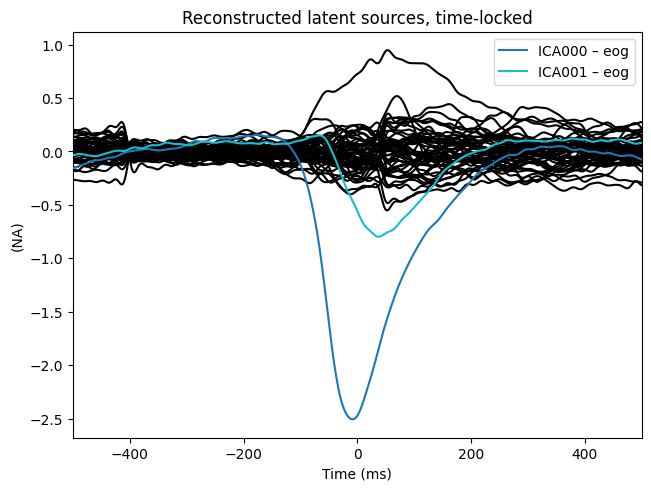

In [25]:
# barplot of ICA component "EOG match" scores
ica.plot_scores(eog_scores)

# plot diagnostics
ica.plot_properties(raw, picks=eog_indices)

# plot ICs applied to raw data, with EOG matches highlighted
ica.plot_sources(raw, show_scrollbars=False)

# plot ICs applied to the averaged EOG epochs, with EOG matches highlighted
ica.plot_sources(eog_evoked)

In [26]:
# APPLICATION ICA COMMUN AVERAGE REFERENCE
ica.apply(epochs)
# https://mne.tools/stable/generated/mne.preprocessing.ICA.html#mne.preprocessing.ICA.apply
# Remove selected components from the signal. Given the unmixing matrix, transform the data, zero out all excluded components, and inverse-transform the data.
# This procedure will reconstruct M/EEG signals from which the dynamics described by the excluded components is subtracted.

Applying ICA to Epochs instance
    Transforming to ICA space (53 components)
    Zeroing out 2 ICA components
    Projecting back using 64 PCA components


<Epochs | 391 events (all good), -0.5 – 0.797 s (baseline off), ~36.4 MiB, data loaded,
 'AV': 130
 'A': 125
 'V': 136>

### Bad channel interpolation

In [ ]:
raw = raw.interpolate_bads()
# https://mne.tools/stable/generated/mne.io.Raw.html#mne.io.Raw.interpolate_bads
# https://mne.tools/stable/auto_examples/preprocessing/interpolate_bad_channels.html

### Save files to derivatives

In [ ]:
epochs.save('/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-1501/sub-1501_preprocessed-epo.fif', overwrite = True)

[PosixPath('/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-1501_preprocessed-epo.fif')]